In [43]:
# Question 1 : Spatial Reasoning & Data Filtering

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box, Point
import rasterio
from rasterio.windows import Window
import numpy as np
from scipy.stats import mode

In [2]:
# Load Delhi-NCR region
delhi_ncr = gpd.read_file("/content/drive/MyDrive/images_folder/delhi_ncr_region.geojson")
print("Original CRS:", delhi_ncr.crs)


Original CRS: EPSG:4326


In [3]:
# Convert to UTM for gridding
delhi_ncr = delhi_ncr.to_crs(epsg=32644)

In [4]:
# Create 60km x 60km grid
grid_size = 60000
xmin, ymin, xmax, ymax = delhi_ncr.total_bounds

grid_cells = []
x = xmin
while x < xmax:
    y = ymin
    while y < ymax:
        cell = box(x, y, x + grid_size, y + grid_size)
        grid_cells.append(cell)
        y += grid_size
    x += grid_size

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=delhi_ncr.crs)
grid = grid[grid.intersects(delhi_ncr.union_all())]

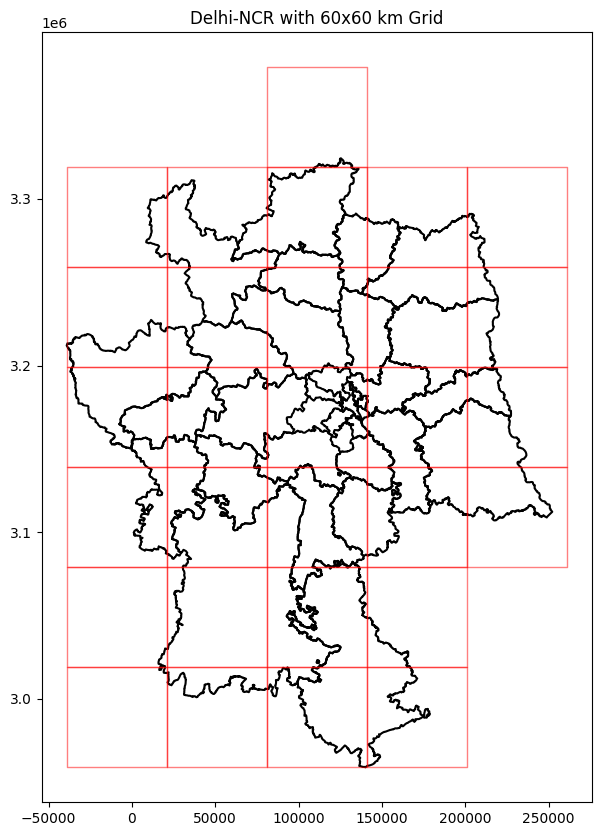

Grid cells: 29


In [5]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 10))
delhi_ncr.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)
grid.plot(ax=ax, facecolor='none', edgecolor='red', alpha=0.5)
plt.title("Delhi-NCR with 60x60 km Grid")
plt.show()
print(f"Grid cells: {len(grid)}")

In [6]:
# Filter satellite images
image_folder = "/content/drive/MyDrive/images_folder/rgb"
image_files = [f for f in os.listdir(image_folder) ]

print(f"Total images: {len(image_files)}")

valid_images = []
for file in image_files:
    try:
        name = file.replace(".png", "")
        lat, lon = name.split("_")
        lat, lon = float(lat), float(lon)

        # Check if inside NCR
        point = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326")
        point = point.to_crs(delhi_ncr.crs)

        if delhi_ncr.contains(point.iloc[0]).any():
            valid_images.append(file)
    except:
        continue

print(f"Images inside NCR: {len(valid_images)}")




Total images: 9216
Images inside NCR: 8015


In [7]:
# Question 2: Label Construction & Dataset Preparation

In [8]:

# Load land cover raster
landcover_path = "/content/drive/MyDrive/images_folder/worldcover_bbox_delhi_ncr_2021.tif"
src = rasterio.open(landcover_path)
print("Raster CRS:", src.crs)

Raster CRS: EPSG:4326


In [9]:
# Extract patches
patch_size = 128
half_size = patch_size // 2

extracted_patches = {}
for file in valid_images:
    if file.endswith(".png"):
        try:
            name = file.replace(".png", "")
            lat, lon = name.split("_")
            lat, lon = float(lat), float(lon)

            row, col = src.index(lon, lat)
            window = Window(col - half_size, row - half_size, patch_size, patch_size)
            patch = src.read(1, window=window)
            extracted_patches[file] = patch
        except Exception as e:
            pass

print(f"Patches extracted: {len(extracted_patches)}")

Patches extracted: 8015


In [10]:
# Assign labels based on dominant class
from collections import Counter

image_labels = {}
for image_name, patch in extracted_patches.items():
    pixels = patch.flatten()
    pixels = pixels[pixels != 0]

    counts = Counter(pixels)
    dominant_class = counts.most_common(1)[0][0]
    image_labels[image_name] = dominant_class

print(f"Images labeled: {len(image_labels)}")

Images labeled: 8015


In [11]:
# Map to land use categories
esa_mapping = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare/sparse vegetation",
    70: "Snow/Ice",
    80: "Water",
    90: "Wetland",
    95: "Mangroves",
    100: "Moss/Lichen"
}

esa_named_labels = {img: esa_mapping.get(lbl, "Unknown")
                     for img, lbl in image_labels.items()}

In [12]:

# Show distribution
class_counts = Counter(image_labels.values())
print("\nTop land cover classes:")
for cls, count in class_counts.most_common(5):
    print(f"Class {cls} ({esa_mapping.get(cls, 'Unknown')}): {count} images")




Top land cover classes:
Class 40 (Cropland): 5473 images
Class 50 (Built-up): 1779 images
Class 10 (Tree cover): 341 images
Class 20 (Shrubland): 247 images
Class 30 (Grassland): 166 images


In [15]:
# Question 3: Model Training & Supervised Evaluation

In [16]:

# Prepare dataset
df = pd.DataFrame(list(esa_named_labels.items()), columns=["image", "label"])
print(f"\nTotal images: {len(df)}")

from sklearn.model_selection import train_test_split

# train_df, test_df = train_test_split(df, test_size=0.4, random_state=42, shuffle=True)
train_df, test_df = train_test_split(
    df,
    test_size=0.4,
    random_state=42,
    stratify=df["label"]   # important line
)

print(f"Train: {len(train_df)}, Test: {len(test_df)}")


Total images: 8015
Train: 4809, Test: 3206



Class Distribution:
Train: {'Cropland': 3284, 'Built-up': 1067, 'Tree cover': 205, 'Shrubland': 148, 'Grassland': 100, 'Water': 4, 'Wetland': 1}
Test: {'Cropland': 2189, 'Built-up': 712, 'Tree cover': 136, 'Shrubland': 99, 'Grassland': 66, 'Water': 3, 'Wetland': 1}


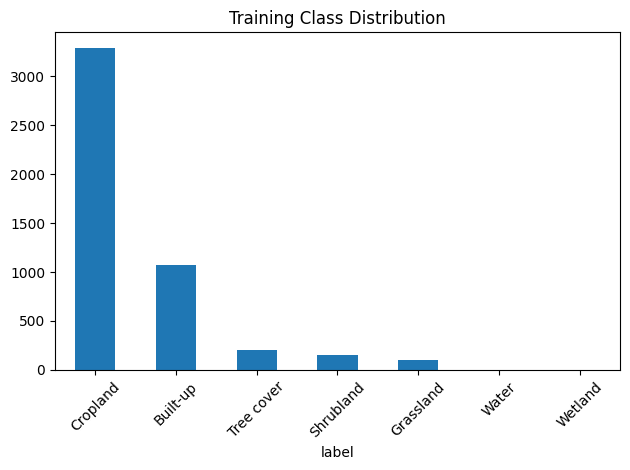

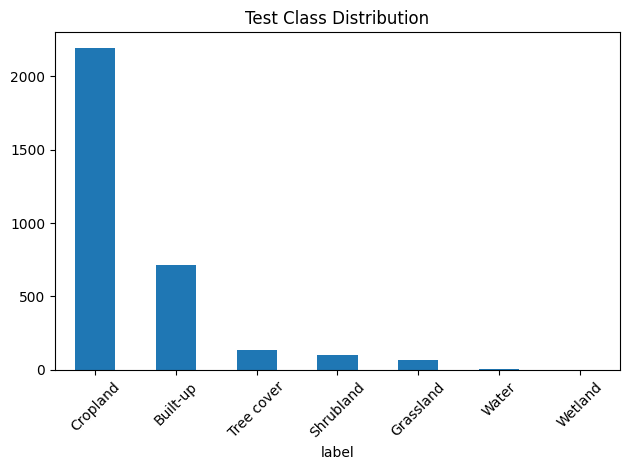

In [17]:
# Show class distribution
print("\nClass Distribution:")
print("Train:", train_df['label'].value_counts().to_dict())
print("Test:", test_df['label'].value_counts().to_dict())

train_df['label'].value_counts().plot(kind='bar', title='Training Class Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_df['label'].value_counts().plot(kind='bar', title='Test Class Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:

# Data loader
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

classes = sorted(df["label"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}
print(f"\nClass mapping: {class_to_idx}")

class ImageDataset(Dataset):
    def __init__(self, dataframe, image_folder, transform=None):
        self.data = dataframe
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]["image"]
        label = self.data.iloc[idx]["label"]

        img_path = os.path.join(self.image_folder, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[label]
        return image, label


Class mapping: {'Built-up': 0, 'Cropland': 1, 'Grassland': 2, 'Shrubland': 3, 'Tree cover': 4, 'Water': 5, 'Wetland': 6}


In [19]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [20]:
train_dataset = ImageDataset(train_df, image_folder, transform)
test_dataset = ImageDataset(test_df, image_folder, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



In [21]:
# CNN Model
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 128 -> 64
        x = self.pool(F.relu(self.conv2(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv3(x)))  # 32 -> 16
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [22]:
model = SimpleCNN(num_classes=len(classes))
device = next(model.parameters()).device

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
# Training
model_path = "/content/drive/MyDrive/images_folder/cnn_model.pth"
# model_path = "/kaggle/working/cnn_model.pth"


if os.path.exists(model_path):
    print("Loading saved model...")
    model.load_state_dict(torch.load(model_path))
    model.eval()
else:
    print("Training model...")
    epochs = 5

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    torch.save(model.state_dict(), model_path)
    print("Model saved")


Training model...
Epoch 1/5, Loss: 0.8216
Epoch 2/5, Loss: 0.5901
Epoch 3/5, Loss: 0.5334
Epoch 4/5, Loss: 0.4849
Epoch 5/5, Loss: 0.4721
Model saved


In [25]:
# Test the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\nTest Accuracy: {accuracy:.2f}%")


Test Accuracy: 84.44%


In [26]:
# Detailed metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))


Accuracy: 0.8444
F1-Score: 0.8127

Classification Report:
              precision    recall  f1-score   support

    Built-up       0.74      0.84      0.79       712
    Cropland       0.88      0.95      0.92      2189
   Grassland       0.00      0.00      0.00        66
   Shrubland       0.00      0.00      0.00        99
  Tree cover       0.74      0.18      0.29       136
       Water       0.00      0.00      0.00         3
     Wetland       0.00      0.00      0.00         1

    accuracy                           0.84      3206
   macro avg       0.34      0.28      0.29      3206
weighted avg       0.80      0.84      0.81      3206



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


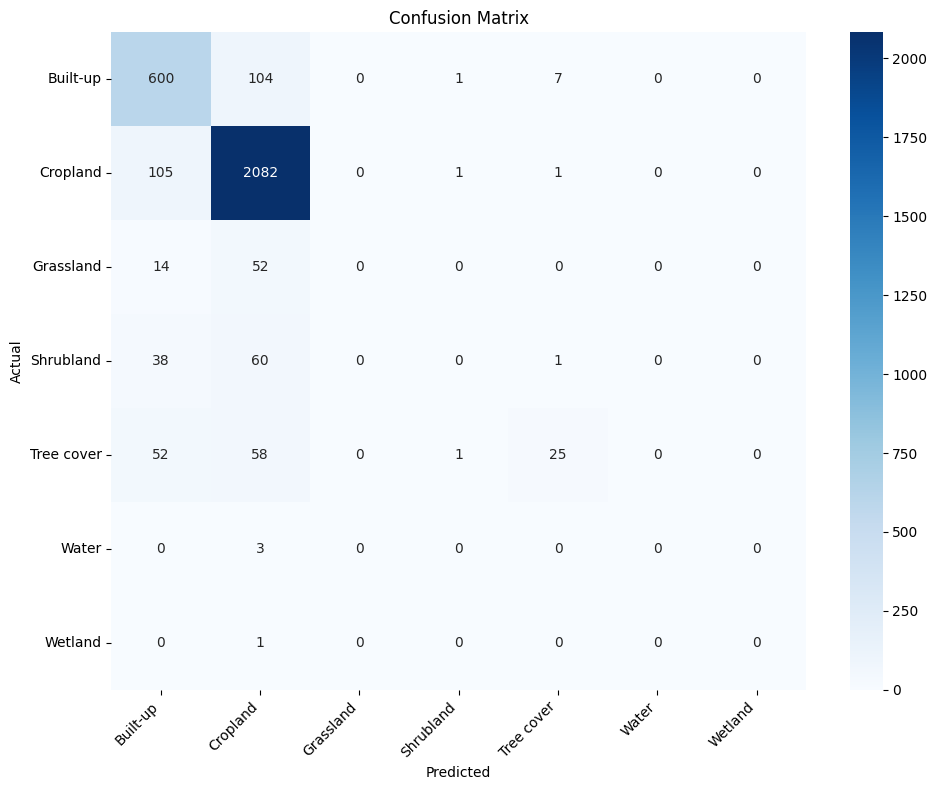

In [27]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [28]:
# Interpretation of Confusion Matrix
print("\nConfusion Matrix Interpretation \n")

# Calculate per-class accuracy
for i, class_name in enumerate(classes):
    correct_pred = cm[i, i]
    total_actual = cm[i].sum()
    accuracy = (correct_pred / total_actual * 100) if total_actual > 0 else 0
    print(f"{class_name:25} - Accuracy: {accuracy:6.2f}% ({correct_pred}/{total_actual})")

print("\nAnalysis ")
print(f"Diagonal values (dark blue): Correct predictions")
print(f"Off-diagonal values (light blue): Misclassifications")

# Identify best and worst performing classes
diagonal = np.diag(cm)
class_accuracies = diagonal / cm.sum(axis=1)
best_class = classes[np.argmax(class_accuracies)]
worst_class = classes[np.argmin(class_accuracies)]

print(f"\nBest performing: {best_class} ({class_accuracies.max()*100:.2f}%)")
print(f" Worst performing: {worst_class} ({class_accuracies.min()*100:.2f}%)")

# Note class imbalance effect
print(f"\nNote: Cropland dominates dataset ")
print(f"Model achieves high accuracy on abundant classes but struggles")
print(f"with minority classes (Water, Bare vegetation, Grassland, Wetland with <10 samples)")


Confusion Matrix Interpretation 

Built-up                  - Accuracy:  84.27% (600/712)
Cropland                  - Accuracy:  95.11% (2082/2189)
Grassland                 - Accuracy:   0.00% (0/66)
Shrubland                 - Accuracy:   0.00% (0/99)
Tree cover                - Accuracy:  18.38% (25/136)
Water                     - Accuracy:   0.00% (0/3)
Wetland                   - Accuracy:   0.00% (0/1)

Analysis 
Diagonal values (dark blue): Correct predictions
Off-diagonal values (light blue): Misclassifications

Best performing: Cropland (95.11%)
 Worst performing: Grassland (0.00%)

Note: Cropland dominates dataset 
Model achieves high accuracy on abundant classes but struggles
with minority classes (Water, Bare vegetation, Grassland, Wetland with <10 samples)
